# Model Evaluation

This notebook evaluates the baseline machine learning models developed in the previous stage.

While baseline metrics such as accuracy and mean absolute error provide an initial indication of performance, deeper diagnostics are required to understand how the models behave across different classes and prediction scenarios.

The evaluation phase focuses on:

* Assessing classification performance using confusion matrices and classification reports.
* Analyzing regression performance using error metrics.
* Inspecting feature importance to understand which variables influence the model's predictions.

These evaluations help verify model reliability and detect potential issues such as overfitting or data leakage before proceeding to further model optimization.


## Import Required Libraries

This section imports the libraries needed for loading the dataset, training the baseline model again for evaluation, and generating diagnostic metrics such as confusion matrices and classification reports.


In [27]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Load Engineered Dataset

The engineered dataset created during the feature engineering stage is loaded again in this notebook. This dataset contains the processed features and target variables required for evaluating the baseline models.


In [28]:
df = pd.read_csv("../data/processed_data/fashion_trend_engineered.csv")

print(df.shape)

df.head()

(1416, 37)


,week,year,month,search_index,search_growth,momentum_4w,keyword_frequency,brand_popularity,avg_price,avg_rating,...,season_Monsoon,season_Summer,season_Winter,category_Jeans,category_Kurti,category_Saree,category_Streetwear,category_TShirt,trend_label,next_week_search
0,4,2021,1,55.04,0.125793,52.5100,153,0.54,1970.19,3.29,...,0,0,1,0,0,0,0,0,2,56.72
1,5,2021,2,56.72,0.030523,53.8450,150,0.46,1758.52,4.40,...,0,0,1,0,0,0,0,0,1,62.65
2,6,2021,2,62.65,0.104549,55.8250,189,0.89,2190.03,4.72,...,0,0,1,0,0,0,0,0,2,58.93
3,7,2021,2,58.93,-0.059377,58.3350,186,0.46,1803.50,4.03,...,0,0,1,0,0,0,0,0,0,64.61
4,8,2021,2,64.61,0.096386,60.7275,201,0.84,1884.70,3.32,...,0,0,1,0,0,0,0,0,2,63.18


## Prepare Features and Target

To evaluate the classification model, the dataset is divided into input features and the target variable.

The target variable for this evaluation is **trend_label**, which represents the trend category. All remaining variables are used as predictive features.


In [29]:
X = df.drop(columns=["trend_label", "next_week_search"])

y = df["trend_label"]

print("Feature shape:", X.shape)

Feature shape: (1416, 35)


## Time-Based Train-Test Split

To ensure consistency with the baseline training stage, the dataset is split chronologically. Earlier observations are used for training while later observations are reserved for testing.

This prevents future information from leaking into the training data and better reflects real-world forecasting conditions.


In [30]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1132, 35)
Test size: (284, 35)


## Train Baseline Classifier

The Random Forest classifier was selected as the best-performing model during the baseline comparison stage.
In this step, the classifier is trained again using the training dataset so that evaluation metrics can be generated on the test dataset.


In [31]:
best_clf = RandomForestClassifier(n_estimators=200, random_state=42)

best_clf.fit(X_train, y_train)

y_pred = best_clf.predict(X_test)

## Confusion Matrix and Classification Report

To evaluate the classification model in more detail, we compute the confusion matrix and classification report.

The confusion matrix shows how many instances from each true class were correctly or incorrectly predicted by the model.

The classification report provides additional metrics such as precision, recall, and F1-score for each class. These metrics help assess whether the model performs consistently across all trend categories.


In [32]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:

[[ 63   0   0]
 [  0 142   0]
 [  0   0  79]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00       142
           2       1.00      1.00      1.00        79

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



## Feature Importance Analysis

To understand how the Random Forest classifier makes predictions, we analyze feature importance.

Feature importance measures how much each feature contributes to the model's decision-making process. This analysis helps identify the most influential variables and can also reveal potential issues such as feature leakage or redundant predictors.


In [33]:
import pandas as pd

feature_importance = pd.Series(
    best_clf.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(15)

search_growth         0.473466
lag_1_search          0.063691
search_index          0.059424
rolling_std_4w        0.058833
keyword_frequency     0.035301
rolling_mean_4w       0.023060
momentum_4w           0.020478
avg_price             0.020294
image_count           0.017672
lag_3_search          0.017413
lag_2_search          0.017227
availability_count    0.014490
week                  0.013770
avg_rating            0.013200
oversized_ratio       0.012510
dtype: float64

## Investigating Potential Feature Leakage

Feature importance analysis revealed that the variable **search_growth** dominates the model's decision-making process.

Since the target variable `trend_label` may be derived from changes in search interest, features such as `search_growth`, `search_index`, and `momentum_4w` could unintentionally reveal information about the target.

To verify whether this causes information leakage, the model will be retrained after removing these potentially leaking features.


In [34]:
X_reduced = X.drop(columns=["search_growth", "search_index", "momentum_4w"])

split_index = int(len(X_reduced) * 0.8)

X_train_red = X_reduced.iloc[:split_index]
X_test_red = X_reduced.iloc[split_index:]

best_clf_red = RandomForestClassifier(n_estimators=200, random_state=42)

best_clf_red.fit(X_train_red, y_train)

y_pred_red = best_clf_red.predict(X_test_red)

print(confusion_matrix(y_test, y_pred_red))
print(classification_report(y_test, y_pred_red))

[[ 33  30   0]
 [ 13 122   7]
 [  2  47  30]]
              precision    recall  f1-score   support

           0       0.69      0.52      0.59        63
           1       0.61      0.86      0.72       142
           2       0.81      0.38      0.52        79

    accuracy                           0.65       284
   macro avg       0.70      0.59      0.61       284
weighted avg       0.68      0.65      0.63       284



## Evaluation After Removing Potential Leakage Features

When the model was trained using all features, it achieved perfect classification accuracy. However, feature importance analysis revealed that the variable `search_growth` dominated the model's decision-making process.

Since the target variable `trend_label` may be derived from search trend changes, this created a form of target leakage.

After removing potential leakage variables (`search_growth`, `search_index`, and `momentum_4w`), the model was retrained. The resulting accuracy decreased to approximately **65%**, indicating that the previous perfect accuracy was largely due to leakage.

This revised evaluation provides a more realistic assessment of the model's ability to predict fashion trends using historical signals and auxiliary features.


## Feature Importance After Removing Leakage Features

After removing variables that could cause target leakage, feature importance is analyzed again to understand which remaining features contribute most to trend prediction.

This analysis helps identify the real signals the model relies on, such as temporal demand patterns, product attributes, or engagement signals.


In [35]:
feature_importance_red = pd.Series(
    best_clf_red.feature_importances_,
    index=X_train_red.columns
)

feature_importance_red = feature_importance_red.sort_values(ascending=False)

feature_importance_red.head(15)

lag_1_search          0.105027
rolling_std_4w        0.097890
keyword_frequency     0.087459
rolling_mean_4w       0.046917
image_count           0.044259
avg_price             0.042746
availability_count    0.039434
lag_3_search          0.038066
lag_2_search          0.037648
avg_rating            0.034079
week                  0.033840
pastel_ratio          0.032530
oversized_ratio       0.032178
dark_ratio            0.031962
cotton_ratio          0.031887
dtype: float64

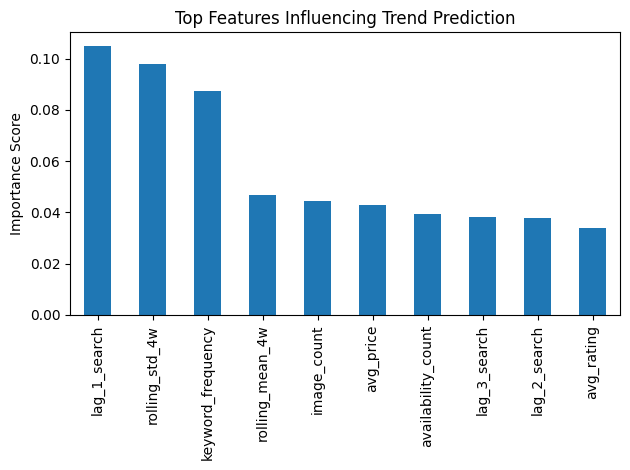

In [36]:
import matplotlib.pyplot as plt

feature_importance_red.head(10).plot(kind="bar")

plt.title("Top Features Influencing Trend Prediction")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.show()